# Fase 5 — Fine-tuning de SciBERT para Clasificación de Texto Científico

**Esquema de transferencia pura:** el modelo se entrena exclusivamente con datos de arXiv  
y se evalúa sobre el corpus UAM-A sin fine-tuning adicional.

**Modelo base:** `allenai/scibert_scivocab_uncased` (preentrenado sobre 1.14M papers científicos)  
**Partición:** 70 / 15 / 15 estratificada (idéntica a Fase 4 — BiLSTM)  
**Entrenamiento:** mixed precision (FP16), early stopping, linear warmup + decay  
**Hardware:** RTX 5090 (34 GB VRAM), Intel Core i9-12900K, 128 GB RAM  
**UAM-A:** 1,112 artículos totales → filtro por idioma inglés → ~746 artículos clasificables

---
## Celda 1 — Imports y configuración

In [2]:
import os
import json
import time
import random
import pickle
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler          # API PyTorch 2.6+
from peft import LoraConfig, get_peft_model, TaskType

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)

from tqdm.auto import tqdm
from langdetect import detect, DetectorFactory

now       = datetime.now()
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")
print(f"Timestamp de ejecución: {date_time}")

#  Semilla para langdetect (reproducibilidad) 
DetectorFactory.seed = 42

#  Rutas de entrada 
AUGMENTED_PATH = r"D:\Aaron\arxiv_cs_top10_augmented.parquet"
UAM_PATH       = r"C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\Articulos.csv"                  # CSV, 1112 artículos

#  Rutas de salida (con estampa de tiempo) 
MODEL_SAVE_PATH = f"scibert_best_{date_time}/"
METRICS_PATH    = f"scibert_metrics_{date_time}.json"
PREDS_PATH      = f"scibert_predictions_uam_{date_time}.parquet"
LABEL_PATH      = f"scibert_label2idx_{date_time}.pkl"

#  Modelo base 
MODEL_NAME = "allenai/scibert_scivocab_uncased"

#  Hiperparámetros 
MAX_LEN       = 512
BATCH_SIZE    = 16       
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.01
EPOCHS        = 10
PATIENCE      = 3        
WARMUP_RATIO  = 0.10     
NUM_CLASSES   = 10
RANDOM_SEED   = 42
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  LoRA 
LORA_R              = 16          
LORA_ALPHA          = 32          
LORA_DROPOUT        = 0.1
LORA_TARGET_MODULES = ["query", "key", "value", "dense"]  # capas de atención

#  Fijar semillas 
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed(RANDOM_SEED)  # transformers seed

#  Reporte 
print(f"\nPyTorch       : {torch.__version__}")
print(f"Device        : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM total    : {vram_total:.1f} GB")
print(f"RAM sistema   : {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"Random seed   : {RANDOM_SEED}")
print(f"LoRA            : r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"LoRA targets    : {LORA_TARGET_MODULES}")
print(f"\nArchivos de salida:")
print(f"  Modelo      : {MODEL_SAVE_PATH}")
print(f"  Métricas    : {METRICS_PATH}")
print(f"  Predicciones: {PREDS_PATH}")
print(f"  label2idx   : {LABEL_PATH}")
print("\n Configuración cargada.")

Timestamp de ejecución: 03_04_2026_11_32_24

PyTorch       : 2.11.0+cu128
Device        : cuda
GPU           : NVIDIA GeForce RTX 5090
VRAM total    : 34.2 GB
RAM sistema   : 137.2 GB
Random seed   : 42
LoRA            : r=16, alpha=32, dropout=0.1
LoRA targets    : ['query', 'key', 'value', 'dense']

Archivos de salida:
  Modelo      : scibert_best_03_04_2026_11_32_24/
  Métricas    : scibert_metrics_03_04_2026_11_32_24.json
  Predicciones: scibert_predictions_uam_03_04_2026_11_32_24.parquet
  label2idx   : scibert_label2idx_03_04_2026_11_32_24.pkl

 Configuración cargada.


---
## Celda 2 — Carga del corpus arXiv aumentado

In [3]:
df = pd.read_parquet(AUGMENTED_PATH)
print(f"Filas totales: {len(df):,}")
print(f"Columnas     : {list(df.columns)}")
print(f"RAM del DataFrame: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RAM proceso       : {psutil.Process().memory_info().rss / 1e9:.2f} GB")

#  Distribución de clases 
print("\n── Distribución de clases (corpus aumentado) ──")
class_counts = df["cs_primary"].value_counts().sort_index()
for cat, cnt in class_counts.items():
    print(f"  {cat:12s} → {cnt:>7,}  ({cnt / len(df) * 100:.2f} %)")

#  Mapeo de etiquetas 
sorted_labels = sorted(df["cs_primary"].unique())
label2idx = {lab: i for i, lab in enumerate(sorted_labels)}
idx2label = {i: lab for lab, i in label2idx.items()}

print(f"\nlabel2idx: {label2idx}")

# Guardar para Fase 7
with open(LABEL_PATH, "wb") as f:
    pickle.dump(label2idx, f)
print(f" label2idx guardado en {LABEL_PATH}")

#  Codificar etiquetas numéricas 
df["label"] = df["cs_primary"].map(label2idx)

#  Pesos de clase: peso_i = N_total / (K × N_i) 
N_total = len(df)
K = NUM_CLASSES
class_weights_list = []
for i in range(NUM_CLASSES):
    n_i = (df["label"] == i).sum()
    class_weights_list.append(N_total / (K * n_i))

# torch.tensor() — nunca torch.from_numpy()
class_weights = torch.tensor(class_weights_list, dtype=torch.float32)
print("\n── Pesos de clase ──")
for i in range(NUM_CLASSES):
    print(f"  {idx2label[i]:12s} → {class_weights[i]:.4f}")

#  Partición 70 / 15 / 15 estratificada 
# Idéntica a Fase 4 (misma semilla, mismo split)
texts_all  = df["texto_limpio"].values
labels_all = df["label"].values

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts_all, labels_all,
    test_size=0.30, stratify=labels_all, random_state=RANDOM_SEED,
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.50, stratify=temp_labels, random_state=RANDOM_SEED,
)

print(f"\n── Partición 70/15/15 ──")
print(f"  Train : {len(train_texts):>8,}  ({len(train_texts)/N_total*100:.1f} %)")
print(f"  Val   : {len(val_texts):>8,}  ({len(val_texts)/N_total*100:.1f} %)")
print(f"  Test  : {len(test_texts):>8,}  ({len(test_texts)/N_total*100:.1f} %)")
print(f"  Total : {len(train_texts)+len(val_texts)+len(test_texts):>8,}")

# Liberar DataFrame — no borrar arrays que se usan en la celda 3
del df, texts_all, labels_all, temp_texts, temp_labels
print(f"\nRAM: {psutil.Process().memory_info().rss / 1e9:.2f} GB")
print("\n Corpus cargado y particionado.")

Filas totales: 713,063
Columnas     : ['title', 'abstract', 'cs_primary', 'texto_limpio', 'aug_method', 'id']
RAM del DataFrame: 1847.3 MB
RAM proceso       : 3.01 GB

── Distribución de clases (corpus aumentado) ──
  cs.AI        →  48,726  (6.83 %)
  cs.CL        →  80,661  (11.31 %)
  cs.CR        →  45,571  (6.39 %)
  cs.CV        → 158,664  (22.25 %)
  cs.DS        →  39,038  (5.47 %)
  cs.IT        →  48,902  (6.86 %)
  cs.LG        → 163,511  (22.93 %)
  cs.NA        →  40,034  (5.61 %)
  cs.RO        →  46,445  (6.51 %)
  cs.SY        →  41,511  (5.82 %)

label2idx: {'cs.AI': 0, 'cs.CL': 1, 'cs.CR': 2, 'cs.CV': 3, 'cs.DS': 4, 'cs.IT': 5, 'cs.LG': 6, 'cs.NA': 7, 'cs.RO': 8, 'cs.SY': 9}
 label2idx guardado en scibert_label2idx_03_04_2026_11_32_24.pkl

── Pesos de clase ──
  cs.AI        → 1.4634
  cs.CL        → 0.8840
  cs.CR        → 1.5647
  cs.CV        → 0.4494
  cs.DS        → 1.8266
  cs.IT        → 1.4581
  cs.LG        → 0.4361
  cs.NA        → 1.7811
  cs.RO        → 1.

---
## Celda 3 — Tokenización con SciBERT

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizador : {MODEL_NAME}")
print(f"Vocab size  : {tokenizer.vocab_size:,}")


def tokenize_split(texts, split_name):
    """Tokeniza un split completo y reporta estadísticas."""
    t0 = time.time()
    encodings = tokenizer(
        list(texts),
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="pt",
    )
    elapsed = time.time() - t0

    # Estadísticas de longitud (tokens reales = sum attention_mask)
    lengths = encodings["attention_mask"].sum(dim=1).numpy()
    pct_truncated = (lengths >= MAX_LEN).mean() * 100

    print(f"\n── {split_name} ──")
    print(f"  Textos       : {len(texts):,}")
    print(f"  Tiempo       : {elapsed:.1f} s")
    print(f"  Long. media  : {lengths.mean():.0f} tokens")
    print(f"  Percentil 90 : {np.percentile(lengths, 90):.0f} tokens")
    print(f"  Truncados    : {pct_truncated:.2f} % (≥ {MAX_LEN} tokens)")

    return encodings


train_enc = tokenize_split(train_texts, "Train")
val_enc   = tokenize_split(val_texts,   "Validación")
test_enc  = tokenize_split(test_texts,  "Test")

print("\n Tokenización completada.")

Tokenizador : allenai/scibert_scivocab_uncased
Vocab size  : 31,090

── Train ──
  Textos       : 499,144
  Tiempo       : 378.5 s
  Long. media  : 182 tokens
  Percentil 90 : 256 tokens
  Truncados    : 0.00 % (≥ 512 tokens)

── Validación ──
  Textos       : 106,959
  Tiempo       : 120.1 s
  Long. media  : 182 tokens
  Percentil 90 : 256 tokens
  Truncados    : 0.00 % (≥ 512 tokens)

── Test ──
  Textos       : 106,960
  Tiempo       : 126.7 s
  Long. media  : 182 tokens
  Percentil 90 : 255 tokens
  Truncados    : 0.00 % (≥ 512 tokens)

 Tokenización completada.


---
## Celda 4 — Dataset y DataLoaders

In [5]:
class SciBERTDataset(Dataset):
    """Dataset para SciBERT: input_ids, attention_mask, label."""

    def __init__(self, encodings, labels):
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label":          self.labels[idx],
        }


train_dataset = SciBERTDataset(train_enc, train_labels)
val_dataset   = SciBERTDataset(val_enc,   val_labels)
test_dataset  = SciBERTDataset(test_enc,  test_labels)

#  DataLoaders 
# num_workers=0 obligatorio en Windows
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    pin_memory=True, num_workers=0,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    pin_memory=True, num_workers=0,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    pin_memory=True, num_workers=0,
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

# Liberar textos crudos — NO borrar encodings (referenciados por Datasets)
#del train_texts, val_texts, test_texts
print(f"RAM: {psutil.Process().memory_info().rss / 1e9:.2f} GB")
print("\n Datasets y DataLoaders listos.")

Train batches : 31,197
Val batches   : 3,343
Test batches  : 3,343
RAM: 52.77 GB

 Datasets y DataLoaders listos.


---
## Celda 5 — Arquitectura SciBERT + LoRA

In [6]:

if torch.cuda.is_available():
    print(f"VRAM antes de cargar modelo: {torch.cuda.memory_allocated() / 1e9:.3f} GB")

# Cargar modelo base (todos los pesos congelados por LoRA automáticamente)
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
)

# Configuración LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
)

# Aplicar LoRA — congela el modelo base y añade adaptadores
model = get_peft_model(base_model, lora_config)
model = model.to(DEVICE)

# Reporte de parámetros 
model.print_trainable_parameters()

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\nModelo          : {MODEL_NAME} + LoRA")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}  ({trainable_params/total_params*100:.2f} %)")
print(f"Frozen params   : {frozen_params:,}  ({frozen_params/total_params*100:.2f} %)")
print(f"LoRA r={LORA_R}, alpha={LORA_ALPHA}, targets={LORA_TARGET_MODULES}")

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved() / 1e9
    print(f"\nVRAM allocated  : {allocated:.3f} GB")
    print(f"VRAM reserved   : {reserved:.3f} GB")

print("\n SciBERT + LoRA cargado en", DEVICE)

VRAM antes de cargar modelo: 0.000 GB


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were ne

trainable params: 2,686,474 || all params: 112,612,628 || trainable%: 2.3856

Modelo          : allenai/scibert_scivocab_uncased + LoRA
Total params    : 112,612,628
Trainable params: 2,686,474  (2.39 %)
Frozen params   : 109,926,154  (97.61 %)
LoRA r=16, alpha=32, targets=['query', 'key', 'value', 'dense']

VRAM allocated  : 0.452 GB
VRAM reserved   : 0.508 GB

 SciBERT + LoRA cargado en cuda


---
## Celda 6 — Configuración del entrenamiento

In [7]:
#  Optimizador 
# Solo se pasan los parámetros entrenables (requires_grad=True)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

#  Pérdida con pesos de clase 
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE)
)

#  Scheduler: linear warmup + linear decay 
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps   = int(WARMUP_RATIO * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
    # NO usar verbose — eliminado en PyTorch 2.6+
)

#  Mixed precision scaler 
scaler = GradScaler("cuda")

print(f"Optimizador         : AdamW (torch.optim)")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Weight decay        : {WEIGHT_DECAY}")
print(f"Total training steps: {num_training_steps:,}")
print(f"Warmup steps        : {num_warmup_steps:,}  ({WARMUP_RATIO*100:.0f} %)")
print(f"Early stopping      : patience = {PATIENCE}")
print(f"Mixed precision     : FP16 (GradScaler)")
print("\n Configuración de entrenamiento lista.")

Optimizador         : AdamW (torch.optim)
Learning rate       : 0.0001
Weight decay        : 0.01
Total training steps: 311,970
Warmup steps        : 31,197  (10 %)
Early stopping      : patience = 3
Mixed precision     : FP16 (GradScaler)

 Configuración de entrenamiento lista.


---
## Celda 7 — Loop de entrenamiento

Iniciando entrenamiento: 10 épocas, 31,197 batches/época


Época 1/10:   0%|          | 0/31197 [00:00<?, ?it/s]

`use_return_dict` is deprecated! Use `return_dict` instead!


Época 01/10 │ Train Loss: 0.6543 │ Val Loss: 0.4816 │ Val F1: 0.8292 │ LR: 1.00e-04 │ Tiempo: 3471s
         │ VRAM alloc: 0.50 GB │ VRAM reserved: 5.38 GB
         │  Nuevo mejor modelo guardado (F1=0.8292)


Época 2/10:   0%|          | 0/31197 [00:00<?, ?it/s]

...

Época 08/10 │ Train Loss: 0.2890 │ Val Loss: 0.5013 │ Val F1: 0.8459 │ LR: 2.22e-05 │ Tiempo: 3608s
         │ VRAM alloc: 0.50 GB │ VRAM reserved: 5.38 GB
         │  Nuevo mejor modelo guardado (F1=0.8459)


Época 9/10:   0%|          | 0/31197 [00:00<?, ?it/s]

Época 09/10 │ Train Loss: 0.2663 │ Val Loss: 0.5333 │ Val F1: 0.8457 │ LR: 1.11e-05 │ Tiempo: 3760s
         │ VRAM alloc: 0.50 GB │ VRAM reserved: 5.38 GB
         │  Sin mejora (1/3)


Época 10/10:   0%|          | 0/31197 [00:00<?, ?it/s]

Época 10/10 │ Train Loss: 0.2473 │ Val Loss: 0.5552 │ Val F1: 0.8456 │ LR: 0.00e+00 │ Tiempo: 3362s
         │ VRAM alloc: 0.50 GB │ VRAM reserved: 5.38 GB
         │  Sin mejora (2/3)

Mejor modelo: época 8, Val Macro F1 = 0.8459
Tiempo total: 35376 s (589.6 min)


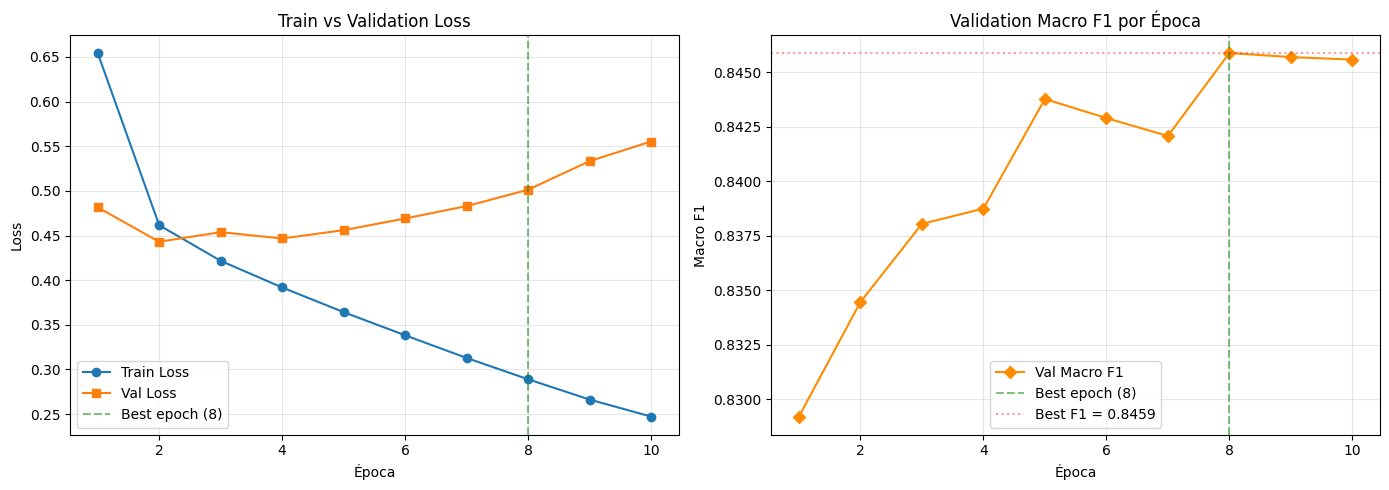

 Gráficas guardadas en scibert_training_curves_03_04_2026_11_32_24.png


In [8]:
def evaluate(model, loader, criterion, device):
    """Evalúa el modelo. Retorna: avg_loss, macro_f1, preds, labels."""
    model.eval()
    running_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            att_mask  = batch["attention_mask"].to(device, non_blocking=True)
            labels    = batch["label"].to(device, non_blocking=True)

            with autocast("cuda"):
                outputs = model(input_ids=input_ids, attention_mask=att_mask)
                logits  = outputs.logits
                loss    = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, macro_f1, all_preds, all_labels


#  Variables de tracking 
history = {
    "train_loss": [], "val_loss": [], "val_f1": [],
    "lr": [], "epoch_time": [],
}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"Iniciando entrenamiento: {EPOCHS} épocas, {len(train_loader):,} batches/época")
print(f"{'='*80}")

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Época {epoch}/{EPOCHS}", leave=True)
    for batch in pbar:
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        att_mask  = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels    = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(input_ids=input_ids, attention_mask=att_mask)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    train_loss = running_loss / len(train_loader.dataset)

    #  Evaluación sobre validación 
    val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    current_lr = scheduler.get_last_lr()[0]
    epoch_time = time.time() - t_epoch

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_time)

    print(
        f"Época {epoch:02d}/{EPOCHS} │ "
        f"Train Loss: {train_loss:.4f} │ "
        f"Val Loss: {val_loss:.4f} │ "
        f"Val F1: {val_f1:.4f} │ "
        f"LR: {current_lr:.2e} │ "
        f"Tiempo: {epoch_time:.0f}s"
    )

    if torch.cuda.is_available():
        print(
            f"         │ VRAM alloc: {torch.cuda.memory_allocated()/1e9:.2f} GB │ "
            f"VRAM reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB"
        )

    #  Early stopping + checkpoint 
    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_epoch       = epoch
        patience_counter = 0
        model.save_pretrained(MODEL_SAVE_PATH)
        tokenizer.save_pretrained(MODEL_SAVE_PATH)
        base_model.config.save_pretrained(MODEL_SAVE_PATH)
        print(f"         │  Nuevo mejor modelo guardado (F1={val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"         │  Sin mejora ({patience_counter}/{PATIENCE})")

    if patience_counter >= PATIENCE:
        print(f"\n Early stopping en época {epoch} — sin mejora en {PATIENCE} épocas.")
        break

epochs_run = epoch
print(f"\n{'='*80}")
print(f"Mejor modelo: época {best_epoch}, Val Macro F1 = {best_val_f1:.4f}")
print(f"Tiempo total: {sum(history['epoch_time']):.0f} s ({sum(history['epoch_time'])/60:.1f} min)")

# ── Gráficas de entrenamiento ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "s-", label="Val Loss")
axes[0].axvline(best_epoch, color="green", ls="--", alpha=0.5, label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["val_f1"], "D-", color="darkorange", label="Val Macro F1")
axes[1].axvline(best_epoch, color="green", ls="--", alpha=0.5, label=f"Best epoch ({best_epoch})")
axes[1].axhline(best_val_f1, color="red", ls=":", alpha=0.4, label=f"Best F1 = {best_val_f1:.4f}")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Validation Macro F1 por Época")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f"scibert_training_curves_{date_time}.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f" Gráficas guardadas en {fig_path}")

In [9]:
import torch

print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    free  = torch.cuda.mem_get_info()[0] / 1e9
    print(f'VRAM total: {total:.1f} GB')
    print(f'VRAM libre: {free:.1f} GB')

CUDA disponible: True
GPU: NVIDIA GeForce RTX 5090
VRAM total: 34.2 GB
VRAM libre: 27.0 GB


In [10]:
from ml_notifier import MLNotifier
notifier = MLNotifier(topic="aaron-ml-lab-2026")

notifier.send(f"Mejor epoca encontrada: {best_epoch}, MF1: {best_val_f1}")



---
## Celda 8 — Evaluación sobre test arXiv

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were ne

Modelo LoRA cargado desde: scibert_best_03_04_2026_11_32_24/


Evaluando test arXiv:   0%|          | 0/3343 [00:00<?, ?it/s]


── Classification Report (test arXiv) ──
              precision    recall  f1-score   support

       cs.AI     0.5931    0.5419    0.5664      7309
       cs.CL     0.8497    0.8948    0.8717     12099
       cs.CR     0.8825    0.8920    0.8872      6835
       cs.CV     0.9033    0.9059    0.9046     23800
       cs.DS     0.9130    0.9211    0.9170      5856
       cs.IT     0.8693    0.9155    0.8918      7336
       cs.LG     0.8420    0.7795    0.8095     24527
       cs.NA     0.9062    0.9106    0.9084      6005
       cs.RO     0.8225    0.9147    0.8662      6967
       cs.SY     0.8080    0.8617    0.8340      6226

    accuracy                         0.8497    106960
   macro avg     0.8390    0.8538    0.8457    106960
weighted avg     0.8482    0.8497    0.8482    106960


 Macro F1 test arXiv: 0.8457


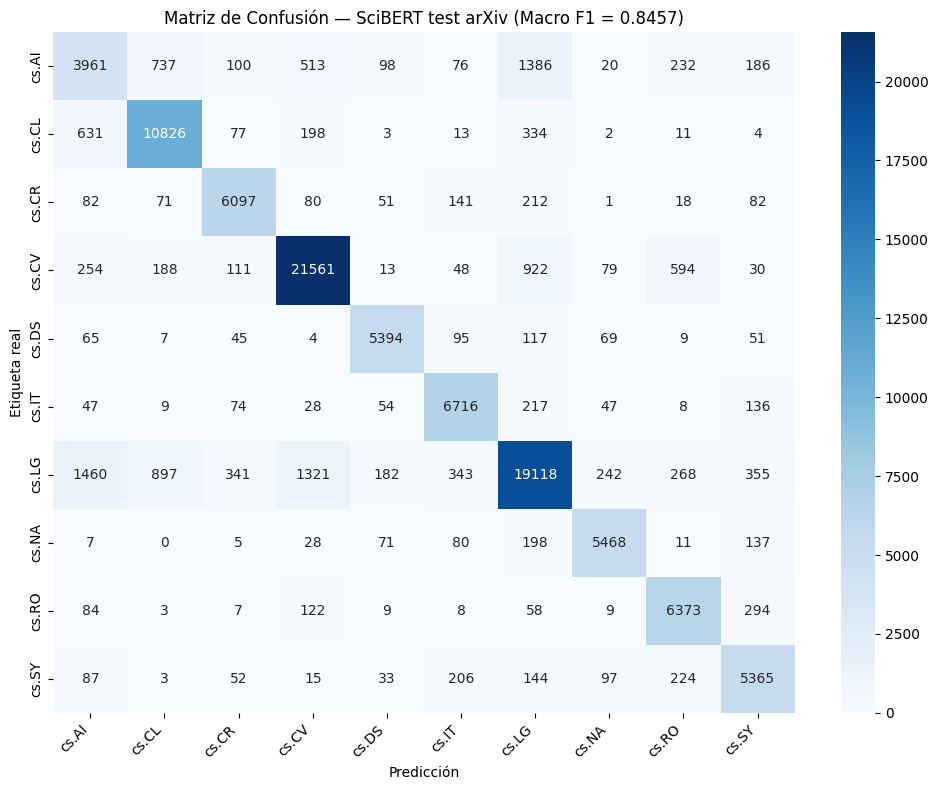


── Patrón cs.AI ↔ cs.LG ──
  cs.AI predicho como cs.LG : 1386
  cs.LG predicho como cs.AI : 1460
  Estado: cs.AI vs cs.LG persiste

── Tabla comparativa ──
Modelo                              |  Macro F1 test arXiv |  Macro F1 UAM-A
------------------------------------+----------------------+----------------
Baseline TF-IDF + LR                |               0.8020 |       pendiente
BiLSTM manual                       |               0.8215 |       pendiente
BiLSTM Optuna                       |               0.8248 |       pendiente
SciBERT fine-tuning                 |               0.8457 |       pendiente

 Evaluación test arXiv completada.


In [11]:
# Reconstruir modelo base + cargar pesos LoRA
from peft import PeftModel

base_for_eval = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,
)

model_best = PeftModel.from_pretrained(base_for_eval, MODEL_SAVE_PATH)
model_best = model_best.to(DEVICE)
model_best.eval()
print(f"Modelo LoRA cargado desde: {MODEL_SAVE_PATH}")

#  Predicciones con inference_mode 
all_preds  = []
all_labels = []

with torch.inference_mode():
    for batch in tqdm(test_loader, desc="Evaluando test arXiv"):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        att_mask  = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels    = batch["label"].to(DEVICE, non_blocking=True)

        with autocast("cuda"):
            outputs = model_best(input_ids=input_ids, attention_mask=att_mask)

        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

target_names = [idx2label[i] for i in range(NUM_CLASSES)]

print("\n── Classification Report (test arXiv) ──")
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

macro_f1_test = f1_score(all_labels, all_preds, average="macro")
print(f"\n Macro F1 test arXiv: {macro_f1_test:.4f}")

#  Matriz de confusión 
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta real")
ax.set_title(f"Matriz de Confusión — SciBERT test arXiv (Macro F1 = {macro_f1_test:.4f})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_path = f"scibert_confusion_test_arxiv_{date_time}.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

#  Análisis de confusión cs.AI vs cs.LG 
ai_idx = label2idx.get("cs.AI", None)
lg_idx = label2idx.get("cs.LG", None)
if ai_idx is not None and lg_idx is not None:
    ai_as_lg = cm[ai_idx, lg_idx]
    lg_as_ai = cm[lg_idx, ai_idx]
    print(f"\n── Patrón cs.AI ↔ cs.LG ──")
    print(f"  cs.AI predicho como cs.LG : {ai_as_lg}")
    print(f"  cs.LG predicho como cs.AI : {lg_as_ai}")
    confusion_resolved = (ai_as_lg + lg_as_ai) < 50
    confusion_pattern = "cs.AI vs cs.LG resuelto" if confusion_resolved else "cs.AI vs cs.LG persiste"
    print(f"  Estado: {confusion_pattern}")
else:
    confusion_pattern = "no evaluado"

# Tabla comparativa 
print(f"\n── Tabla comparativa ──")
print(f"{'Modelo':<35s} | {'Macro F1 test arXiv':>20s} | {'Macro F1 UAM-A':>15s}")
print(f"{'-'*35}-+-{'-'*20}-+-{'-'*15}")
print(f"{'Baseline TF-IDF + LR':<35s} | {'0.8020':>20s} | {'pendiente':>15s}")
print(f"{'BiLSTM manual':<35s} | {'0.8215':>20s} | {'pendiente':>15s}")
print(f"{'BiLSTM Optuna':<35s} | {'0.8248':>20s} | {'pendiente':>15s}")
print(f"{'SciBERT fine-tuning':<35s} | {macro_f1_test:>20.4f} | {'pendiente':>15s}")

print("\n Evaluación test arXiv completada.")

---
## Celda 9 — Evaluación de transferencia pura sobre UAM-A

In [16]:
df_uam_en.to_parquet("uam_a_dataset.parquet")

UAM-A total: 1,112 artículos
Columnas   : ['Resumen']

Detectando idioma (langdetect)...

── Distribución de idiomas (UAM-A) ──
  en         →   746  (67.1 %)
  es         →   360  (32.4 %)
  fr         →     6  (0.5 %)

Artículos en inglés: 746 de 1,112
Tokenización: 0.8 s


Predicciones UAM-A:   0%|          | 0/24 [00:00<?, ?it/s]

Distribución de predicciones sobre UAM-A (inglés):
pred_scibert
cs.AI    283
cs.NA    213
cs.SY    134
cs.DS     69
cs.CR     23
cs.RO     16
cs.IT      4
cs.CV      3
cs.CL      1


NameError: name 'OUTPUT_DIR' is not defined

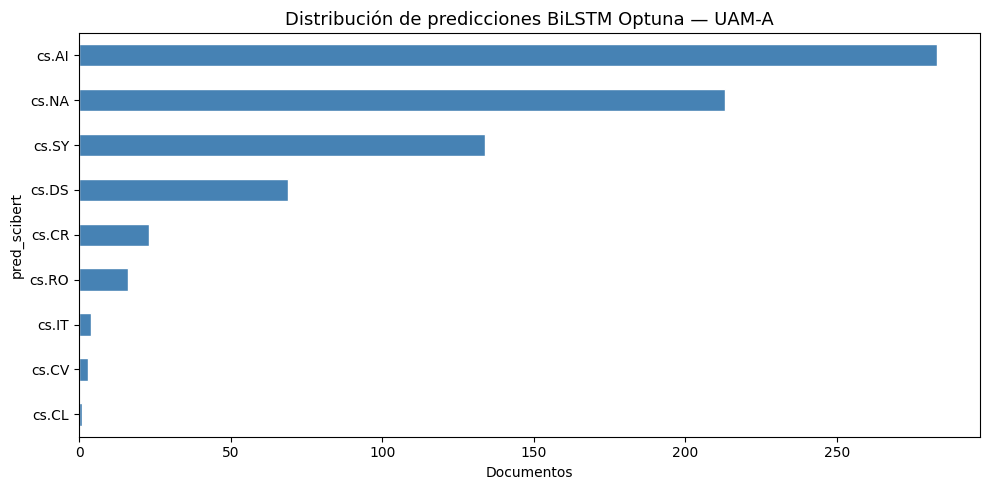

In [12]:
#  Cargar CSV con los 1,112 artículos 
df_uam = pd.read_csv(UAM_PATH)
print(f"UAM-A total: {len(df_uam):,} artículos")
print(f"Columnas   : {list(df_uam.columns)}")

#  Detectar columna de texto 
text_col = "Resumen"

#  Filtro de idioma con langdetect 
print("\nDetectando idioma (langdetect)...")


def detect_language_safe(text):
    """Detecta idioma con fallback a 'unknown' para textos vacíos."""
    if not isinstance(text, str) or len(text.strip()) < 20:
        return "unknown"
    try:
        return detect(text)
    except Exception:
        return "unknown"


df_uam["lang"] = df_uam[text_col].apply(detect_language_safe)

lang_dist = df_uam["lang"].value_counts()
print("\n── Distribución de idiomas (UAM-A) ──")
for lang, cnt in lang_dist.items():
    print(f"  {lang:10s} → {cnt:>5d}  ({cnt/len(df_uam)*100:.1f} %)")

# Filtrar solo inglés
df_uam_en = df_uam.loc[df_uam["lang"] == "en"].reset_index(drop=True)
print(f"\nArtículos en inglés: {len(df_uam_en):,} de {len(df_uam):,}")

if len(df_uam_en) == 0:
    raise ValueError("No se encontraron artículos en inglés en UAM-A.")

#  Tokenizar abstracts en inglés 
t0 = time.time()
uam_texts = df_uam_en[text_col].fillna("").tolist()
uam_enc = tokenizer(
    uam_texts, max_length=MAX_LEN, truncation=True,
    padding="max_length", return_tensors="pt",
)
print(f"Tokenización: {time.time()-t0:.1f} s")

#  Dataset sin etiquetas 
class SciBERTDatasetNoLabel(Dataset):
    def __init__(self, encodings):
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
    def __len__(self):
        return self.input_ids.size(0)
    def __getitem__(self, idx):
        return {"input_ids": self.input_ids[idx], "attention_mask": self.attention_mask[idx]}

uam_loader = DataLoader(
    SciBERTDatasetNoLabel(uam_enc), batch_size=BATCH_SIZE * 2,
    shuffle=False, pin_memory=True, num_workers=0,
)

#  Predicciones 
uam_preds = []
with torch.inference_mode():
    for batch in tqdm(uam_loader, desc="Predicciones UAM-A"):
        input_ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        att_mask  = batch["attention_mask"].to(DEVICE, non_blocking=True)

        with autocast("cuda"):
            outputs = model_best(input_ids=input_ids, attention_mask=att_mask)

        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        uam_preds.extend(preds)

df_uam_en["pred_scibert_idx"] = uam_preds
df_uam_en["pred_scibert"]     = [idx2label[p] for p in uam_preds]

#  Distribución de predicciones 
print("Distribución de predicciones sobre UAM-A (inglés):")
print(pd.Series(df_uam_en["pred_scibert"]).value_counts().to_string())

fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(df_uam_en["pred_scibert"]).value_counts().sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title("Distribución de predicciones BiLSTM Optuna — UAM-A", fontsize=13)
ax.set_xlabel("Documentos")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}\\bilstm_optuna_uam_distribution_{date_time}.png", dpi=150)
plt.show()

---
## Celda 10 — Guardar resultados y métricas

In [14]:
macro_f1_uam =None

metrics = {
    "timestamp":           date_time,
    "macro_f1_val_arxiv":  best_val_f1,
    "macro_f1_test_arxiv": macro_f1_test,
    "macro_f1_uam":        macro_f1_uam if macro_f1_uam is not None else "sin ground truth",
    "best_epoch":          best_epoch,
    "uam_articles_total":  len(df_uam),
    "uam_articles_english": len(df_uam_en),
    "hyperparameters": {
        "max_len":       MAX_LEN,
        "batch_size":    BATCH_SIZE,
        "lr":            LEARNING_RATE,
        "weight_decay":  WEIGHT_DECAY,
        "warmup_ratio":  WARMUP_RATIO,
        "epochs_run":    epochs_run,
        "lora_r":        LORA_R,
        "lora_alpha":    LORA_ALPHA,
        "lora_dropout":  LORA_DROPOUT,
        "lora_targets":  LORA_TARGET_MODULES,
    },
    "confusion_pattern": confusion_pattern,
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f" Métricas guardadas en {METRICS_PATH}")

# ── Verificar archivos generados ───────────────────────────
outputs_list = [
    (MODEL_SAVE_PATH, "Modelo + tokenizador (save_pretrained)"),
    (LABEL_PATH,      "Mapeo label2idx"),
    (PREDS_PATH,      "Predicciones UAM-A"),
    (METRICS_PATH,    "Métricas JSON"),
]

print("\n── Archivos generados (Fase 5) ──")
for path, desc in outputs_list:
    exists = os.path.exists(path)
    icon   = "OK" if exists else "NO"
    size   = ""
    if exists:
        if os.path.isdir(path):
            total = sum(
                os.path.getsize(os.path.join(dp, f))
                for dp, _, fnames in os.walk(path) for f in fnames
            )
            size = f" ({total / 1e6:.1f} MB)"
        else:
            size = f" ({os.path.getsize(path) / 1e6:.1f} MB)"
    print(f"  {icon} {path:<55s} — {desc}{size}")

# ── Resumen final ──────────────────────────────────────────
print(f"\n{'='*80}")
print(f"RESUMEN FASE 5 — SciBERT Fine-tuning")
print(f"{'='*80}")
print(f"  Timestamp         : {date_time}")
print(f"  Modelo base       : {MODEL_NAME}")
print(f"  LoRA            : r={LORA_R}, alpha={LORA_ALPHA}, targets={LORA_TARGET_MODULES}")
print(f"  Épocas ejecutadas : {epochs_run}")
print(f"  Mejor época       : {best_epoch}")
print(f"  Val Macro F1      : {best_val_f1:.4f}")
print(f"  Test Macro F1     : {macro_f1_test:.4f}")
if macro_f1_uam is not None:
    print(f"  UAM-A Macro F1    : {macro_f1_uam:.4f}")
else:
    print(f"  UAM-A Macro F1    : sin ground truth")
print(f"  UAM-A artículos   : {len(df_uam_en)} en inglés de {len(df_uam)} totales")
print(f"  Patrón confusión  : {confusion_pattern}")
print(f"{'='*80}")

print(f"\n── Tabla comparativa final ──")
print(f"{'Modelo':<35s} | {'Macro F1 test arXiv':>20s} | {'Macro F1 UAM-A':>15s}")
print(f"{'-'*35}-+-{'-'*20}-+-{'-'*15}")
print(f"{'Baseline TF-IDF + LR':<35s} | {'0.8020':>20s} | {'pendiente':>15s}")
print(f"{'BiLSTM manual':<35s} | {'0.8215':>20s} | {'pendiente':>15s}")
print(f"{'BiLSTM Optuna':<35s} | {'0.8248':>20s} | {'pendiente':>15s}")
uam_str = f"{macro_f1_uam:.4f}" if macro_f1_uam is not None else "pendiente"
print(f"{'SciBERT fine-tuning':<35s} | {macro_f1_test:>20.4f} | {uam_str:>15s}")

print("\n Fase 5 completada.")

 Métricas guardadas en scibert_metrics_03_04_2026_11_32_24.json

── Archivos generados (Fase 5) ──
  OK scibert_best_03_04_2026_11_32_24/                       — Modelo + tokenizador (save_pretrained) (11.5 MB)
  OK scibert_label2idx_03_04_2026_11_32_24.pkl               — Mapeo label2idx (0.0 MB)
  NO scibert_predictions_uam_03_04_2026_11_32_24.parquet     — Predicciones UAM-A
  OK scibert_metrics_03_04_2026_11_32_24.json                — Métricas JSON (0.0 MB)

RESUMEN FASE 5 — SciBERT Fine-tuning
  Timestamp         : 03_04_2026_11_32_24
  Modelo base       : allenai/scibert_scivocab_uncased
  LoRA            : r=16, alpha=32, targets=['query', 'key', 'value', 'dense']
  Épocas ejecutadas : 10
  Mejor época       : 8
  Val Macro F1      : 0.8459
  Test Macro F1     : 0.8457
  UAM-A Macro F1    : sin ground truth
  UAM-A artículos   : 746 en inglés de 1112 totales
  Patrón confusión  : cs.AI vs cs.LG persiste

── Tabla comparativa final ──
Modelo                              |  Macro

In [ ]:
from transformers import AutoModelForSequenceClassification

model_tmp = AutoModelForSequenceClassification.from_pretrained(
    "allenai/scibert_scivocab_uncased", num_labels=10
)

# Mostrar todas las capas lineales
for name, module in model_tmp.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"  {name:<50s} → {module.in_features} × {module.out_features}")

del model_tmp
